# GDD_ENS DP-SGD: utility vs. membership-leakage trade-off

Trains the single-MLP GDD_ENS target with **DP-SGD** (Opacus) at several privacy budgets ε, runs LiRA + RMIA + population at each, and reports test accuracy vs. attack performance. The ε = ∞ point is the non-DP baseline from `gdd_main.ipynb`.

**Prerequisite:** run `gdd_main.ipynb` first (it builds and caches `data/gdd_ens.pkl`, the shared population this notebook reuses).

**Shadows are trained under DP too.** The target stores `dpsgd=True` in its metadata `init_params`, so LeakPro rebuilds shadow models with `dpsgd=True` and trains them under the *same* ε — a calibrated LiRA/RMIA, not DP-target-vs-non-DP-shadows.

> **Shadow-cache gotcha (why each ε gets its own `output_dir`).** LeakPro keys the shadow-model cache on the training recipe (`init_params`, optimizer, epochs) — which is *identical* across ε, because the DP noise level lives in `dpsgd_dic.pkl`, not in `init_params`. If every ε wrote to the same `output_dir`, the shadows trained at the first ε would be silently reused for all the others. We therefore give each ε a distinct `output_dir` (`leakpro_output_dpsgd/eps_<ε>`) so its shadows retrain against that ε's noise.

In [1]:
import os
import sys
import yaml

project_root = os.path.abspath(os.path.join(os.getcwd(), '../../..'))
sys.path.insert(0, project_root)

In [2]:
import pickle

from gdd_data_handler import GddDataHandler

with open('train_config_dpsgd.yaml', 'r') as file:
    train_config = yaml.safe_load(file)

data_dir = train_config['data']['data_dir']
dataset_name = train_config['data']['dataset']
population_path = os.path.join(data_dir, 'gdd_ens.pkl')

if not os.path.exists(population_path):
    raise FileNotFoundError(
        f'{population_path} not found. Run gdd_main.ipynb first to build the cached population.')

with open(population_path, 'rb') as file:
    population_dataset = pickle.load(file)
print('Population size:', len(population_dataset))

/home/edvin/leakpro-workspace/LeakPro/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Population size: 36976


In [3]:
import numpy as np
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader

np.random.seed(train_config['run']['random_seed'])

train_fraction = train_config['data']['f_train']
test_fraction = train_config['data']['f_test']
batch_size = train_config['train']['batch_size']

dataset_size = len(population_dataset)
train_size = int(train_fraction * dataset_size)
test_size = int(test_fraction * dataset_size)

selected_index = np.random.choice(np.arange(dataset_size), train_size + test_size, replace=False)
train_indices, test_indices = train_test_split(selected_index, test_size=test_size)

data = population_dataset.data
targets = population_dataset.targets
train_subset = GddDataHandler.UserDataset(data[train_indices], targets[train_indices])
test_subset = GddDataHandler.UserDataset(data[test_indices], targets[test_indices])

train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_subset, batch_size=batch_size, shuffle=False)

input_size = data.shape[1]
num_classes = int(targets.max().item()) + 1
print(f'Train: {len(train_subset)} | Test: {len(test_subset)} | '
      f'features: {input_size} | classes: {num_classes}')

Train: 11092 | Test: 7395 | features: 4599 | classes: 38


## The ε sweep

`EPSILON_GRID` is the set of finite budgets to train. For each ε we (1) write `dpsgd_dic.pkl`, (2) train a DP target, (3) write a per-ε audit config with its own `output_dir`, (4) run the audit. Smaller ε = more noise = lower utility and (expected) lower attack AUC.

On 38 highly-imbalanced classes, small ε will hit rare tumor types hardest — inspect macro accuracy, not just overall.

In [17]:
from torch import nn, optim, save

from gdd_model_handler_dpsgd import GddModelHandlerDPsgd
from utils.gdd_model_dpsgd import GddMLP_DPsgd
from leakpro import LeakPro

EPSILON_GRID = [1.0, 2.0, 4.0, 8.0]  # epsilon = infinity is the non-DP baseline (gdd_main.ipynb)

log_dir = train_config['run']['log_dir']
lr = train_config['train']['learning_rate']
weight_decay = train_config['train']['weight_decay']
epochs = train_config['train']['epochs']
virtual_batch_size = train_config['train']['virtual_batch_size']
dp = train_config['dp']
os.makedirs(log_dir, exist_ok=True)

with open('audit_dpsgd.yaml', 'r') as f:
    base_audit_cfg = yaml.safe_load(f)


def write_privacy_config(target_epsilon):
    cfg = {
        'target_epsilon': target_epsilon,
        'target_delta': dp['target_delta'],
        'epochs': epochs,
        'epsilon_tolerance': dp['epsilon_tolerance'],
        'eps_error': dp['eps_error'],
        'accountant': dp['accountant'],
        'max_grad_norm': dp['max_grad_norm'],
    }
    path = os.path.join(log_dir, 'dpsgd_dic.pkl')
    with open(path, 'wb') as fh:
        pickle.dump(cfg, fh)
    return path


def write_audit_config(target_epsilon):
    cfg = {**base_audit_cfg}
    cfg['audit'] = {**base_audit_cfg['audit'],
                    'output_dir': f'./leakpro_output_dpsgd/eps_{target_epsilon}'}
    path = f'audit_dpsgd_eps_{target_epsilon}.yaml'
    with open(path, 'w') as fh:
        yaml.safe_dump(cfg, fh, sort_keys=False)
    return path

In [18]:
def tpr_at_fpr(result, target_fpr):
    """Linearly interpolate TPR at a target FPR from a MIAResult's ROC arrays."""
    fpr = np.asarray(result.fpr, dtype=float)
    tpr = np.asarray(result.tpr, dtype=float)
    order = np.argsort(fpr)
    return float(np.interp(target_fpr, fpr[order], tpr[order]))


def attack_name(result):
    return getattr(result, 'result_name', None) or getattr(result, 'id', type(result).__name__)


rows = []
for eps in EPSILON_GRID:
    print(f'\n===== epsilon = {eps} =====')
    privacy_config_path = write_privacy_config(eps)

    model = GddMLP_DPsgd(input_size=input_size, num_classes=num_classes, dpsgd=True)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    train_result = GddModelHandlerDPsgd().train(
        dataloader=train_loader, model=model, criterion=criterion, optimizer=optimizer,
        epochs=epochs, dpsgd_metadata_path=privacy_config_path,
        virtual_batch_size=virtual_batch_size)
    target_model = train_result.model
    test_result = GddModelHandlerDPsgd().eval(test_loader, target_model, criterion)

    target_model.to('cpu')
    with open(os.path.join(log_dir, 'target_model.pkl'), 'wb') as f:
        save(target_model.state_dict(), f)
    meta_data = LeakPro.make_mia_metadata(
        train_result=train_result, optimizer=optimizer, loss_fn=criterion,
        dataloader=train_loader, test_result=test_result, epochs=epochs,
        train_indices=train_indices, test_indices=test_indices, dataset_name=dataset_name)
    with open(os.path.join(log_dir, 'model_metadata.pkl'), 'wb') as f:
        pickle.dump(meta_data, f)
    print(f'  target train acc {train_result.metrics.accuracy:.4f} | '
          f'test acc {test_result.accuracy:.4f}')

    audit_path = write_audit_config(eps)
    leakpro = LeakPro(GddDataHandler, audit_path, model_handler=GddModelHandlerDPsgd)
    mia_results = leakpro.run_audit(create_pdf=True)

    for res in mia_results:
        rows.append({
            'epsilon': eps,
            'test_acc': test_result.accuracy,
            'attack': attack_name(res),
            'roc_auc': float(getattr(res, 'roc_auc', np.nan)),
            'tpr@fpr=1e-2': tpr_at_fpr(res, 1e-2),
            'tpr@fpr=1e-3': tpr_at_fpr(res, 1e-3),
        })

2026-06-18 08:05:14,434 INFO     DP-SGD config loaded from ./target_dpsgd/dpsgd_dic.pkl: {'target_epsilon': 1.0, 'target_delta': 1e-05, 'epochs': 20, 'epsilon_tolerance': 0.01, 'eps_error': 0.01, 'accountant': 'rdp', 'max_grad_norm': 1.0}
06/18/2026 08:05:14:INFO:DP-SGD config loaded from ./target_dpsgd/dpsgd_dic.pkl: {'target_epsilon': 1.0, 'target_delta': 1e-05, 'epochs': 20, 'epsilon_tolerance': 0.01, 'eps_error': 0.01, 'accountant': 'rdp', 'max_grad_norm': 1.0}
/home/edvin/leakpro-workspace/LeakPro/.venv/lib/python3.12/site-packages/opacus/accountants/analysis/rdp.py:332: UserWarning: Optimal order is the largest alpha. Please consider expanding the range of alphas to get a tighter privacy bound.
  warnings.warn(
/home/edvin/leakpro-workspace/LeakPro/.venv/lib/python3.12/site-packages/opacus/privacy_engine.py:98: UserWarning: Secure RNG turned off. This is perfectly fine for experimentation as it allows for much faster training performance, but remember to turn it on and retrain on


===== epsilon = 1.0 =====


Epoch 1/20:   0%|          | 0/347 [00:00<?, ?it/s]sys:1: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.
Epoch 1/20: 489it [00:01, 291.13it/s]                         
Epoch 2/20: 492it [00:01, 290.00it/s]                         
Epoch 3/20: 494it [00:01, 296.44it/s]                         
Epoch 4/20: 501it [00:01, 298.46it/s]                         
Epoch 5/20: 498it [00:01, 297.53it/s]                         
Epoch 6/20: 507it [00:01, 370.53it/s]                         
Epoch 7/20: 490it [00:01, 406.10it/s]                         
Epoch 8/20: 506it [00:01, 413.89it/s]                         
Epoch 9/20: 515it [00:01, 348.96it/s]                         
Epoch 10/20: 493it [00:01, 300.70it/s]                         
Epoch 11/20: 518it [00:01, 305.70it/s]     

  target train acc 0.2070 | test acc 0.2045


2026-06-18 08:05:47,491 INFO     Loaded population dataset from ./data/gdd_ens.pkl
06/18/2026 08:05:47:INFO:Loaded population dataset from ./data/gdd_ens.pkl
2026-06-18 08:05:47,493 INFO     MIA attack factory loaded.
06/18/2026 08:05:47:INFO:MIA attack factory loaded.
2026-06-18 08:05:47,494 INFO     Shadow model handler singleton already exists, updating state
06/18/2026 08:05:47:INFO:Shadow model handler singleton already exists, updating state
2026-06-18 08:05:47,495 INFO     Created folder ./leakpro_output_dpsgd/eps_1.0/attack_objects/shadow_model
06/18/2026 08:05:47:INFO:Created folder ./leakpro_output_dpsgd/eps_1.0/attack_objects/shadow_model
Getting Model Logits: 100%|██████████| 1/1 [00:00<00:00,  1.11it/s]
2026-06-18 08:05:48,460 INFO     Saved logits to ./leakpro_output_dpsgd/eps_1.0/attack_cache/target_f1143e234cad1cebd9de10d5289ae30e4ff8e533e55dd17331f88ca9c920f3dc_logits.npy
06/18/2026 08:05:48:INFO:Saved logits to ./leakpro_output_dpsgd/eps_1.0/attack_cache/target_f1143e

...


===== epsilon = 8.0 =====


/home/edvin/leakpro-workspace/LeakPro/.venv/lib/python3.12/site-packages/opacus/privacy_engine.py:98: UserWarning: Secure RNG turned off. This is perfectly fine for experimentation as it allows for much faster training performance, but remember to turn it on and retrain one last time before production with ``secure_mode`` turned on.
  warnings.warn(
Epoch 1/20:   0%|          | 0/347 [00:00<?, ?it/s]sys:1: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.
Epoch 1/20: 485it [00:01, 284.78it/s]                         
Epoch 2/20: 511it [00:01, 286.94it/s]                         
Epoch 3/20: 496it [00:01, 286.95it/s]                         
Epoch 4/20: 499it [00:01, 285.48it/s]                         
Epoch 5/20: 485it [00:01, 284.70it/s]                         
Epoch 6

  target train acc 0.2405 | test acc 0.2262


2026-06-18 08:35:58,347 INFO     Loaded population dataset from ./data/gdd_ens.pkl
06/18/2026 08:35:58:INFO:Loaded population dataset from ./data/gdd_ens.pkl
2026-06-18 08:35:58,349 INFO     MIA attack factory loaded.
06/18/2026 08:35:58:INFO:MIA attack factory loaded.
2026-06-18 08:35:58,350 INFO     Shadow model handler singleton already exists, updating state
06/18/2026 08:35:58:INFO:Shadow model handler singleton already exists, updating state
2026-06-18 08:35:58,352 INFO     Created folder ./leakpro_output_dpsgd/eps_8.0/attack_objects/shadow_model
06/18/2026 08:35:58:INFO:Created folder ./leakpro_output_dpsgd/eps_8.0/attack_objects/shadow_model
Getting Model Logits: 100%|██████████| 1/1 [00:05<00:00,  5.98s/it]
2026-06-18 08:36:04,441 INFO     Saved logits to ./leakpro_output_dpsgd/eps_8.0/attack_cache/target_ea7675e4703f7345eecb08c01236c5e8d5e1b87ee206d459b769f9a463449711_logits.npy
06/18/2026 08:36:04:INFO:Saved logits to ./leakpro_output_dpsgd/eps_8.0/attack_cache/target_ea7675

<Figure size 640x480 with 0 Axes>

In [22]:
import pandas as pd

trade_off = pd.DataFrame(rows)
trade_off.to_csv('dpsgd_tradeoff.csv', index=False)
trade_off

,epsilon,test_acc,attack,roc_auc,tpr@fpr=1e-2,tpr@fpr=1e-3
0,1.0,0.204462,LiRA,0.499869,0.008835,0.000992
1,2.0,0.197160,LiRA,0.498635,0.009917,0.001352
2,4.0,0.238404,LiRA,0.495489,0.010638,0.001262
3,8.0,0.226234,LiRA,0.492374,0.008475,0.000721


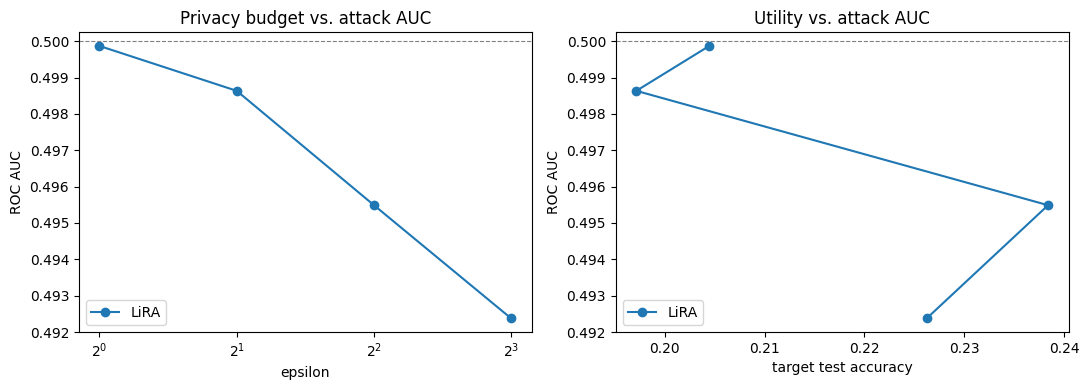

In [23]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
for name, grp in trade_off.groupby('attack'):
    grp = grp.sort_values('epsilon')
    ax1.plot(grp['epsilon'], grp['roc_auc'], marker='o', label=name)
    ax2.plot(grp['test_acc'], grp['roc_auc'], marker='o', label=name)
ax1.set_xlabel('epsilon'); ax1.set_ylabel('ROC AUC'); ax1.set_xscale('log', base=2)
ax1.axhline(0.5, color='grey', ls='--', lw=0.8); ax1.set_title('Privacy budget vs. attack AUC'); ax1.legend()
ax2.set_xlabel('target test accuracy'); ax2.set_ylabel('ROC AUC')
ax2.axhline(0.5, color='grey', ls='--', lw=0.8); ax2.set_title('Utility vs. attack AUC'); ax2.legend()
plt.tight_layout(); plt.show()

Add the ε = ∞ row by reading the non-DP AUCs from `leakpro_output/results/*/result.txt` (produced by `gdd_main.ipynb`) and appending them to `trade_off` before plotting, if you want ∞ on the same axes.

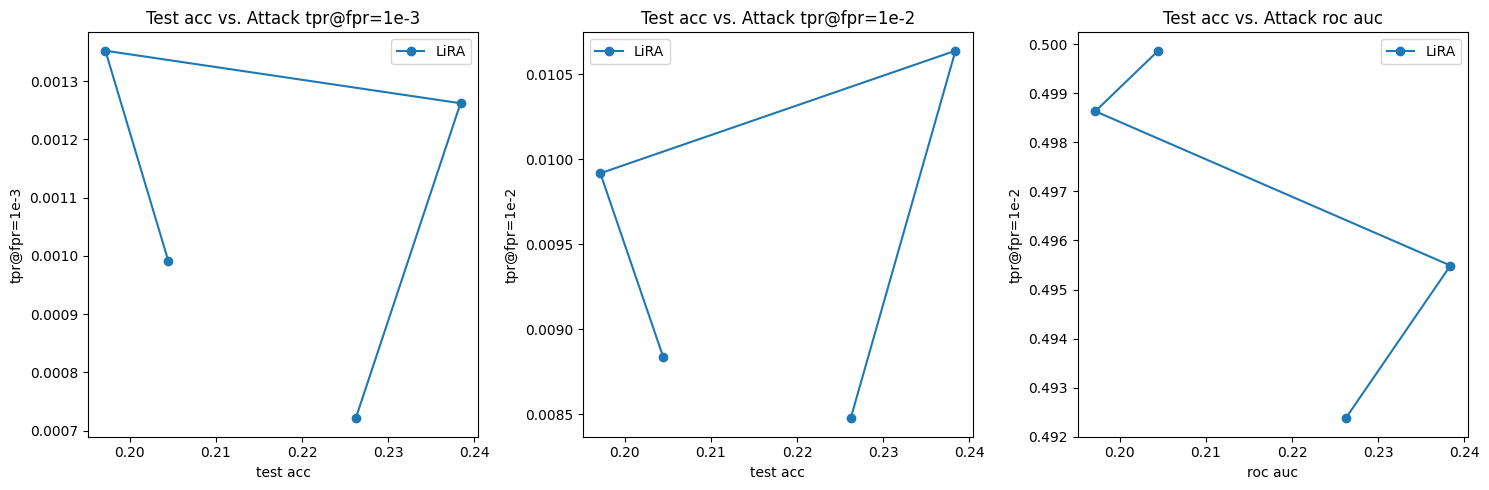

In [25]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))
for name, grp in trade_off.groupby('attack'):
    grp = grp.sort_values('epsilon')
    ax1.plot(grp['test_acc'], grp['tpr@fpr=1e-3'], marker='o', label=name)
    ax2.plot(grp['test_acc'], grp['tpr@fpr=1e-2'], marker='o', label=name)
    ax3.plot(grp['test_acc'], grp['roc_auc'], marker='o', label=name)

ax1.set_xlabel('test acc')
ax1.set_ylabel('tpr@fpr=1e-3')
ax1.set_title('Test acc vs. Attack tpr@fpr=1e-3')
ax1.legend()

ax2.set_xlabel('test acc')
ax2.set_ylabel('tpr@fpr=1e-2')
ax2.set_title('Test acc vs. Attack tpr@fpr=1e-2')
ax2.legend()

ax3.set_xlabel('roc auc')
ax3.set_ylabel('tpr@fpr=1e-2')
ax3.set_title('Test acc vs. Attack roc auc')
ax3.legend()

plt.tight_layout()
plt.show()